# Plate Detection

## Train/Val

In [1]:
pip install -qqq albumentations

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install -qqq ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 70.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
from ultralytics import YOLO

# Load a YOLOv8 model
model = YOLO("yolo12n.pt")
model.to('cuda')
# Train the model
train_plate = model.train(data="/kaggle/input/ocr-yolo-tts/Combine/Plate/data.yaml",    
    epochs=100,
    batch=64,
    imgsz=640,
    auto_augment = 'autoaugment',
    augment = True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 5.34M/5.34M [00:00<00:00, 70.2MB/s]


engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=autoaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/ocr-yolo-tts/Combine/Plate/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=None, rect=False, resume=False,

100%|██████████| 755k/755k [00:00<00:00, 16.4MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  2    180864  ultralytics.nn.modules.block.A2C2f           [128, 128, 2, True, 4]        
  7                  -1  1    295424  ultralytics

...

    100/100        12G     0.8044     0.2948     0.9581         26        640: 100%|██████████| 211/211 [03:12<00:00,  1.09it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 31/31 [00:21<00:00,  1.45it/s]

                   all       3848       3985      0.984      0.974      0.987       0.75



100 epochs completed in 5.988 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train/weights/best.pt, 5.5MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.158 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12n summary (fused): 159 layers, 2,556,923 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 31/31 [00:38<00:00,  1.23s/it]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all       3848       3985      0.982      0.973      0.988      0.741
Speed: 0.1ms preprocess, 6.5ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detect/train


## Test

In [4]:
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')
test_plate = model.val(data="/kaggle/input/ocr-yolo-tts/Combine/Plate/data.yaml",imgsz=640, split = 'test')

Ultralytics 8.3.158 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12n summary (fused): 159 layers, 2,556,923 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.5 ms, read: 3.8±1.9 MB/s, size: 33.1 KB)


val: Scanning /kaggle/input/ocr-yolo-tts/Combine/Plate/test/labels... 1923 images, 10 backgrounds, 1 corrupt: 100%|██████████| 1924/1924 [00:15<00:00, 123.77it/s]

val: /kaggle/input/ocr-yolo-tts/Combine/Plate/test/images/quandoi63.jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/ocr-yolo-tts/Combine/Plate/test/images/quandoi63.jpg'


WARNING ⚠️ val: Cache directory /kaggle/input/ocr-yolo-tts/Combine/Plate/test is not writeable, cache not saved.
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 66, len(boxes) = 1976. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 121/121 [00:15<00:00,  7.60it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all       1923       1976      0.986      0.981      0.992      0.761
Speed: 0.2ms preprocess, 3.8ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detect/val


# OCR

## OCR Train/Val

In [5]:
from ultralytics import YOLO

# Load a YOLOv8 model
model = YOLO("yolo12n.pt")
model.to('cuda')
# Train the model
train_ocr = model.train(data="/kaggle/input/ocr-yolo-tts/Combine/Char/data.yaml",    
    epochs=100,
    batch=64,
    imgsz=640,
    auto_augment = 'augmix',
    augment = True
)

engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=augmix, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/ocr-yolo-tts/Combine/Char/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=None, rect=False, resume=False, reti

train: Scanning /kaggle/input/ocr-yolo-tts/Combine/Char/train/labels... 2683 images, 7 backgrounds, 0 corrupt: 100%|██████████| 2683/2683 [00:22<00:00, 119.55it/s]

train: /kaggle/input/ocr-yolo-tts/Combine/Char/train/images/ndata148.jpg: 1 duplicate labels removed
train: /kaggle/input/ocr-yolo-tts/Combine/Char/train/images/ndata301.jpg: 1 duplicate labels removed


WARNING ⚠️ train: Cache directory /kaggle/input/ocr-yolo-tts/Combine/Char/train is not writeable, cache not saved.
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2.6±1.1 MB/s, size: 22.8 KB)


val: Scanning /kaggle/input/ocr-yolo-tts/Combine/Char/valid/labels... 766 images, 4 backgrounds, 0 corrupt: 100%|██████████| 766/766 [00:06<00:00, 116.01it/s]


...

    100/100      12.4G     0.6478     0.2776     0.9213        472        640: 100%|██████████| 42/42 [00:39<00:00,  1.06it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:04<00:00,  1.25it/s]

                   all        766       6196      0.976      0.981      0.986      0.761



100 epochs completed in 1.287 hours.
Optimizer stripped from runs/detect/train2/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train2/weights/best.pt, 5.5MB

Validating runs/detect/train2/weights/best.pt...
Ultralytics 8.3.158 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12n summary (fused): 159 layers, 2,562,578 parameters, 0 gradients, 6.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:08<00:00,  1.50s/it]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        766       6196      0.973      0.974      0.984      0.759
                     1        530        817      0.987      0.989      0.987      0.645
                     2        395        527      0.987      0.987      0.992      0.795
                     3        321        414       0.99      0.978      0.991      0.788
                     4        307        388      0.993      0.995      0.991      0.748
                     5        528        772      0.991      0.996      0.994      0.792
                     6        354        455       0.99      0.996      0.988      0.778
                     7        313        412      0.988      0.978      0.982      0.758
                     8        322        409      0.976      0.978      0.989      0.767
                     9        439        578      0.987      0.995       0.99      0.788
                     A         79         83      0.978          1      0.994      0.774
                     

## OCR Test

In [6]:
model = YOLO('/kaggle/working/runs/detect/train2/weights/best.pt')
test_ocr = model.val(data="/kaggle/input/ocr-yolo-tts/Combine/Char/data.yaml",imgsz=640, split='test')

Ultralytics 8.3.158 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12n summary (fused): 159 layers, 2,562,578 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2.1±0.7 MB/s, size: 17.8 KB)


val: Scanning /kaggle/input/ocr-yolo-tts/Combine/Char/test/labels... 384 images, 0 backgrounds, 0 corrupt: 100%|██████████| 384/384 [00:03<00:00, 125.72it/s]


WARNING ⚠️ val: Cache directory /kaggle/input/ocr-yolo-tts/Combine/Char/test is not writeable, cache not saved.


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 24/24 [00:04<00:00,  5.90it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        384       3124      0.964      0.978       0.98      0.763
                     1        263        409      0.991      0.995      0.994        0.7
                     2        188        253      0.993          1      0.992      0.786
                     3        164        217      0.994      0.995      0.995      0.812
                     4        167        213      0.993          1      0.994      0.758
                     5        251        347      0.997      0.994      0.995      0.786
                     6        174        231      0.994      0.974      0.994      0.795
                     7        171        224      0.996      0.988      0.992      0.791
                     8        151        189      0.983      0.995      0.992      0.784
                     9        232        311          1          1      0.995      0.793
                     A         36         36      0.991          1      0.995      0.751
                     

# Test Plate+OCR

In [7]:
import cv2
from matplotlib import pyplot as plt

In [8]:
plate_detection = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')
plate_ocr = YOLO('/kaggle/working/runs/detect/train2/weights/best.pt')


0: 448x640 1 License_Plate, 54.7ms
Speed: 2.0ms preprocess, 54.7ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)
Results saved to runs/detect/predict


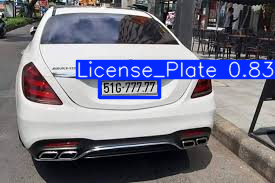

In [9]:
img = cv2.imread('/kaggle/input/2222222222/images.jpg')

results = plate_detection(img, save = True, imgsz = 640)
results[0].show()

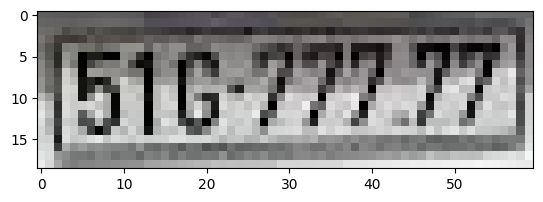


0: 224x640 1 1, 1 5, 5 7s, 1 G, 52.3ms
Speed: 0.9ms preprocess, 52.3ms inference, 1.5ms postprocess per image at shape (1, 3, 224, 640)
Results saved to runs/detect/predict2


Detected text: 51G77777


In [10]:
for box in results[0].boxes:
    class_id = int(box.cls[0])
    
    # If it's a license plate
    if class_id == 0:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        plate_crop = img[y1:y2, x1:x2]

        # Display cropped plate
        plt.imshow(plate_crop)
        plt.show()

        # Perform OCR on the cropped plate
        text_plate = plate_ocr(plate_crop, save=True, imgsz=640)

        # Get OCR predictions
        ocr_pre = text_plate[0]
        ocr_pre.show()

        id2char = plate_ocr.names
        boxes = ocr_pre.boxes
        cls_ids = boxes.cls.cpu().numpy().astype(int)
        
        # Sort by Y coordinate 
        sorted_boxes = sorted(zip(boxes.xyxy.cpu().numpy(), cls_ids), key=lambda b: b[0][1]) 
        rows = []
        current_row = []
        last_y = -1
        threshold = 10 
        
        for box, cls_id in sorted_boxes:
            x1, y1, x2, y2 = box
            if last_y == -1 or abs(y1 - last_y) < threshold:  
                current_row.append((x1, cls_id)) 
            else:
                rows.append(current_row)  
                current_row = [(x1, cls_id)] 
            last_y = y1
        
        # Add the last row
        if current_row:
            rows.append(current_row)

        # Sort each row by X coordinate 
        detected_text = []
        for row in rows:
            sorted_row = sorted(row, key=lambda item: item[0]) 
            # Extract characters for the row
            row_text = ''.join([id2char[cls_id] for _, cls_id in sorted_row])
            detected_text.append(row_text)

        # Join all rows and output final text
        final_text = ''.join(detected_text)
        print("Detected text:", final_text)